## Section 1

In [156]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

### Parameters

In [160]:
# Top coins: 1.BTC  2.ETH   3.USDT  4.XRP   5.SOL   6.BNB
# We discarrd USDT since it is almost stable (and stationary)
coins = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'SOL-USD', 'BNB-USD']

start_date = '2023-11-01'
end_date = '2024-11-01'

time_frames = ['1h', '4h', '1d']

### Download Data

In [161]:
all_data = {}
for coin in coins:
    all_data[coin] = {}
    for time_frame in time_frames:
        if time_frame != '4h':
            data = yf.download(coin, start=start_date, end=end_date, interval=time_frame)
            all_data[coin][time_frame] = data
        else:
            data = all_data[coin]['1h']
            data.columns = data.columns.get_level_values(0)
            data_4h = data.resample('4H').agg({
                'Open': 'first',
                'High': 'max',
                'Low': 'min',
                'Close': 'last',
                'Volume': 'sum'
            }).dropna() 
            all_data[coin][time_frame] = data_4h

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Plot Data

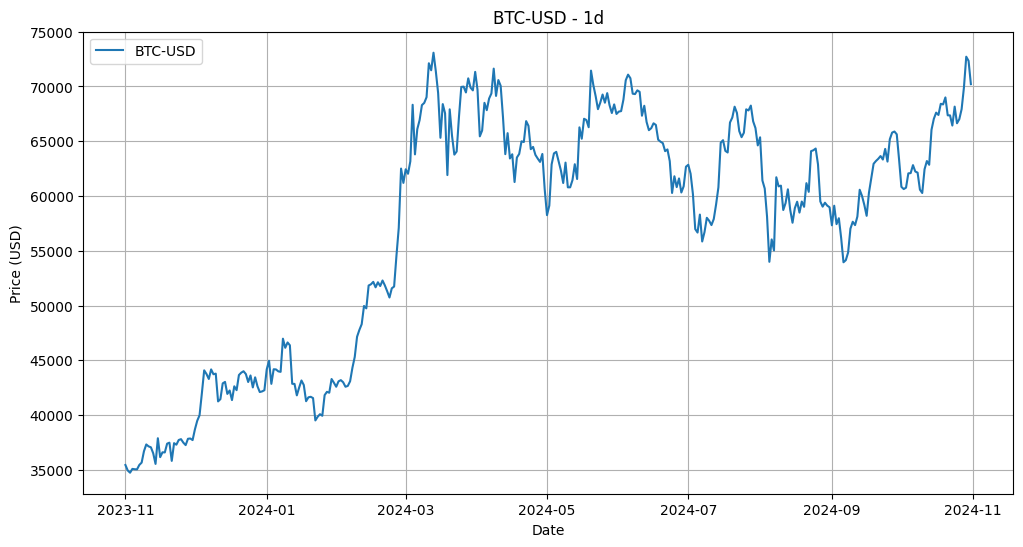

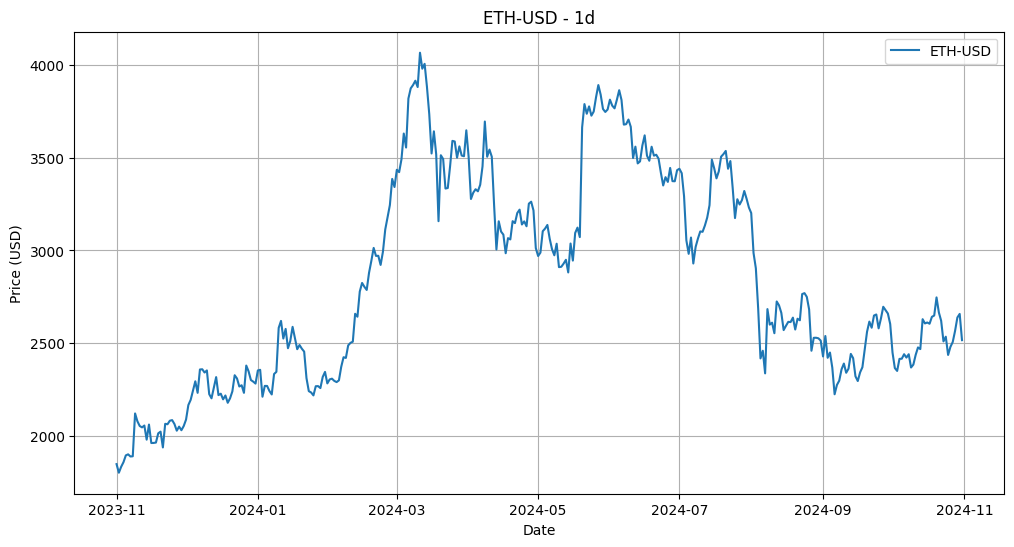

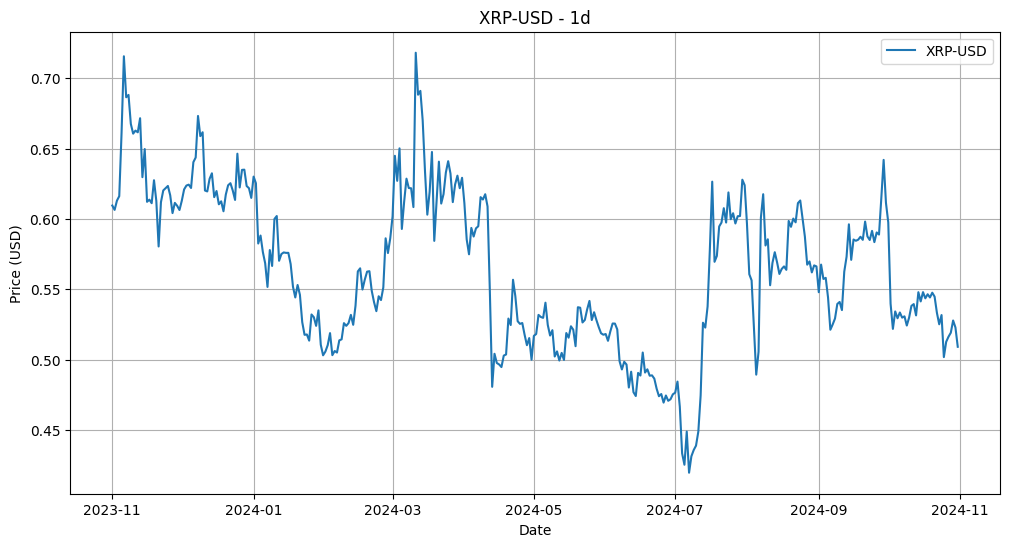

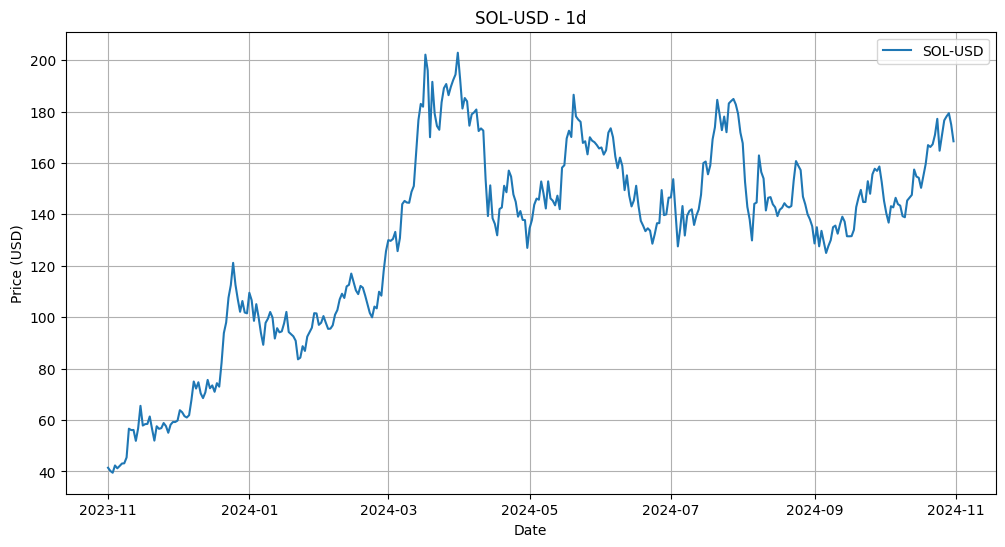

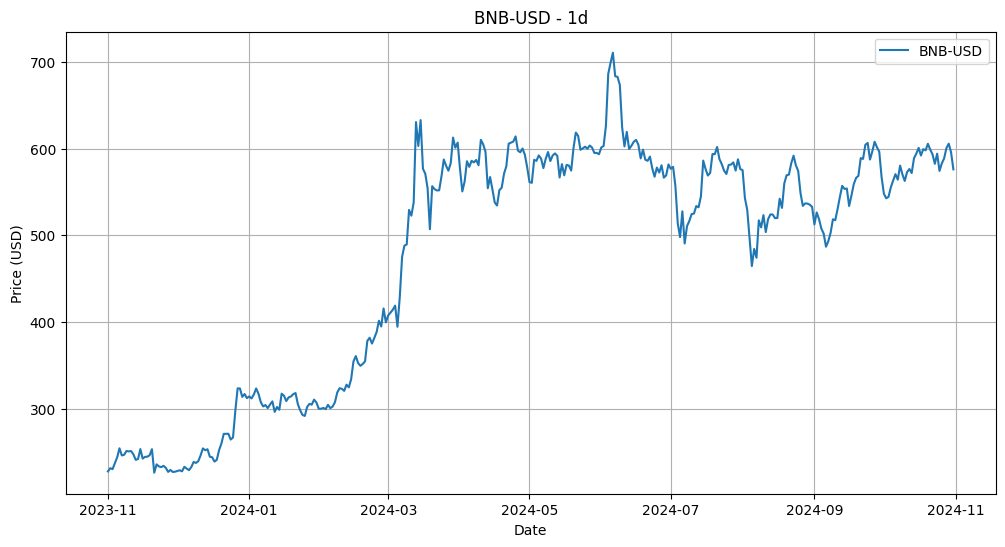

In [162]:
def plot_data(coin, interval='1d'):
    plt.figure(figsize=(12, 6))
    data = all_data[coin][interval]
    plt.plot(data.index, data['Close'], label=f'{coin}')
    plt.title(f'{coin} - {interval}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.grid()
    plt.legend()
    plt.show()

for coin in coins:
    plot_data(coin)
    # for time_frame in time_frames:
    #     plot_data(coin, time_frame)

### ADF Test & Stationary

In [163]:
def perform_adf_test(data):
    result = adfuller(data['Close'].dropna())
    return result

def check_stationary(pvalue):
    return pvalue < 0.1

all_adf = {}
all_stationary = {}
for coin in coins:
    all_adf[coin] = {}
    all_stationary[coin] = {}
    for time_frame in time_frames:
        res = perform_adf_test(all_data[coin][time_frame])
        stats, pvalue = res[0], res[1]
        all_adf[coin][time_frame] = (stats, pvalue)
        all_stationary[coin][time_frame] = check_stationary(pvalue)

### Report

Among top 6 coins, considering 1d, 1h and 4h dataframes, `XRP` and `USDT` are recognized as stationary, however `USDT` is ignored here. The corresponding `p-value`s are less than 0.1 assuring mean and variance. Also the `Global Local Test` showed no seasonality. 

In [164]:
for coin in coins:
    for time_frame in time_frames:
        print(coin, "-", time_frame)
        print(f"ADF Statistics: {all_adf[coin][time_frame][0]}\tP-value: {all_adf[coin][time_frame][1]}")
        if all_stationary[coin][time_frame]:
            print("Stationary!")
        else:
            print("Not Stationary!")
        print(100*"=")

BTC-USD - 1h
ADF Statistics: -1.7320205463539893	P-value: 0.41469459384658214
Not Stationary!
BTC-USD - 4h
ADF Statistics: -1.8501576924759	P-value: 0.3558591725232182
Not Stationary!
BTC-USD - 1d
ADF Statistics: -1.7836611113318483	P-value: 0.3886031366528824
Not Stationary!
ETH-USD - 1h
ADF Statistics: -2.042437024266687	P-value: 0.2682813310443846
Not Stationary!
ETH-USD - 4h
ADF Statistics: -1.972734547402233	P-value: 0.2986544947797005
Not Stationary!
ETH-USD - 1d
ADF Statistics: -2.0434127180785753	P-value: 0.2678683168721533
Not Stationary!
XRP-USD - 1h
ADF Statistics: -3.1575462749798286	P-value: 0.022577376766632226
Stationary!
XRP-USD - 4h
ADF Statistics: -3.0611103675557647	P-value: 0.0295682915616204
Stationary!
XRP-USD - 1d
ADF Statistics: -3.2715006204524126	P-value: 0.016201463684109393
Stationary!
SOL-USD - 1h
ADF Statistics: -2.2458262424809585	P-value: 0.19003534156012558
Not Stationary!
SOL-USD - 4h
ADF Statistics: -2.217136957234169	P-value: 0.20008462421751477
Not 

Here we select `BTC` as non-stationary coin.

### ACF & PACF

1h
4h
1d


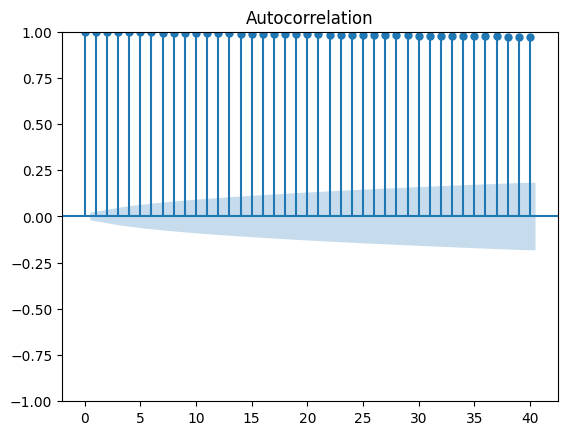

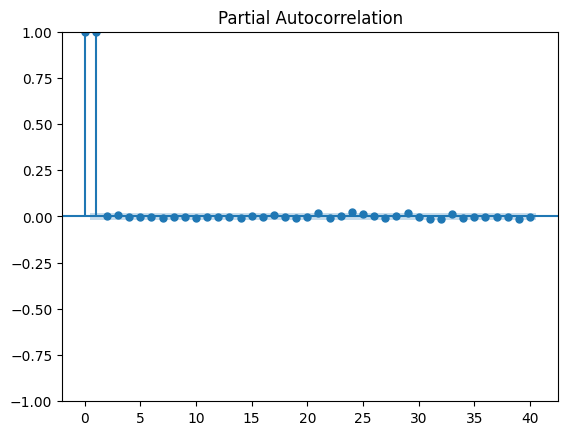

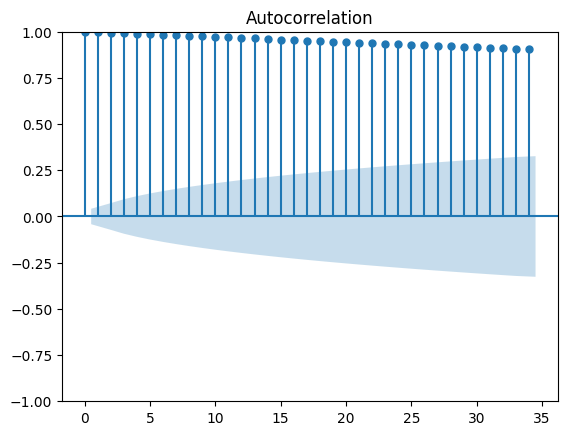

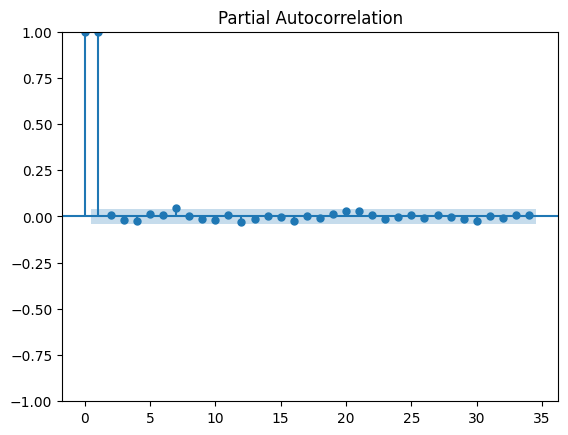

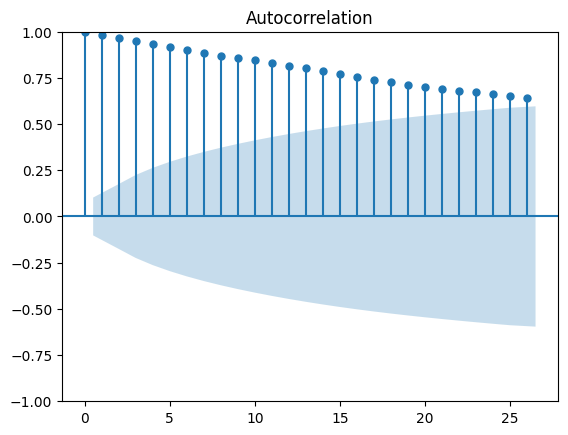

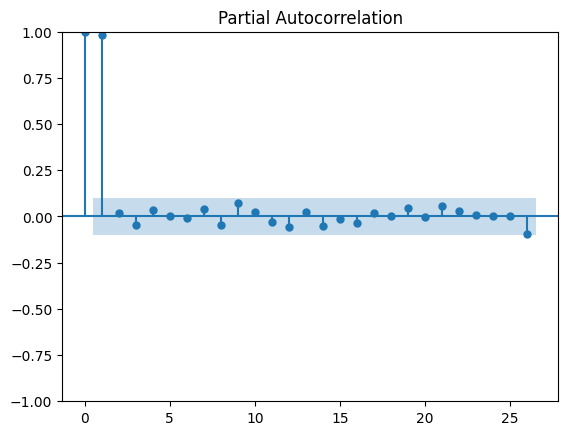

In [165]:
coin = 'BTC-USD'
for time_frame in time_frames:
    print(time_frame)
    plot_acf(all_data[coin][time_frame]['Close'].dropna())
    plot_pacf(all_data[coin][time_frame]['Close'].dropna())

### Fit AR, MA and ARIMA Model
According to ACF and PACF plots, `ACF` values are not very meaningful so we use `PACF` values for `AR` model with parameter `p`. `p-value`s are as follows:

(high spike, out of error band and a significant decrease observed in the next one)

P:  1d: 1   4h: 1   1h: 1

Q:  1d: 1   4h: 1   1h: 1

In [166]:
coin = 'BTC-USD'  
series_1d = all_data[coin]['1d']['Close'].dropna()
series_4h = all_data[coin]['4h']['Close'].dropna()  
series_1h = all_data[coin]['1h']['Close'].dropna()
 
train_data_1d = series_1d[:'2024-10-01']
test_data_1d = series_1d['2024-10-01':]

train_data_4h = series_4h[:'2024-10-01']
test_data_4h = series_4h['2024-10-01':]

train_data_1h = series_1h[:'2024-10-01']
test_data_1h = series_1h['2024-10-01':]

### AR Models

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8064
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -57854.955
Date:                Mon, 16 Dec 2024   AIC                         115715.910
Time:                        21:20:52   BIC                         115736.896
Sample:                    11-01-2023   HQIC                        115723.090
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.632e+04   6323.033      8.907      0.000    4.39e+04    6.87e+04
ar.L1          0.9996      0.000   3655.396      0.000       0.999       1.000
sigma2      9.981e+04    645.931    154.522      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


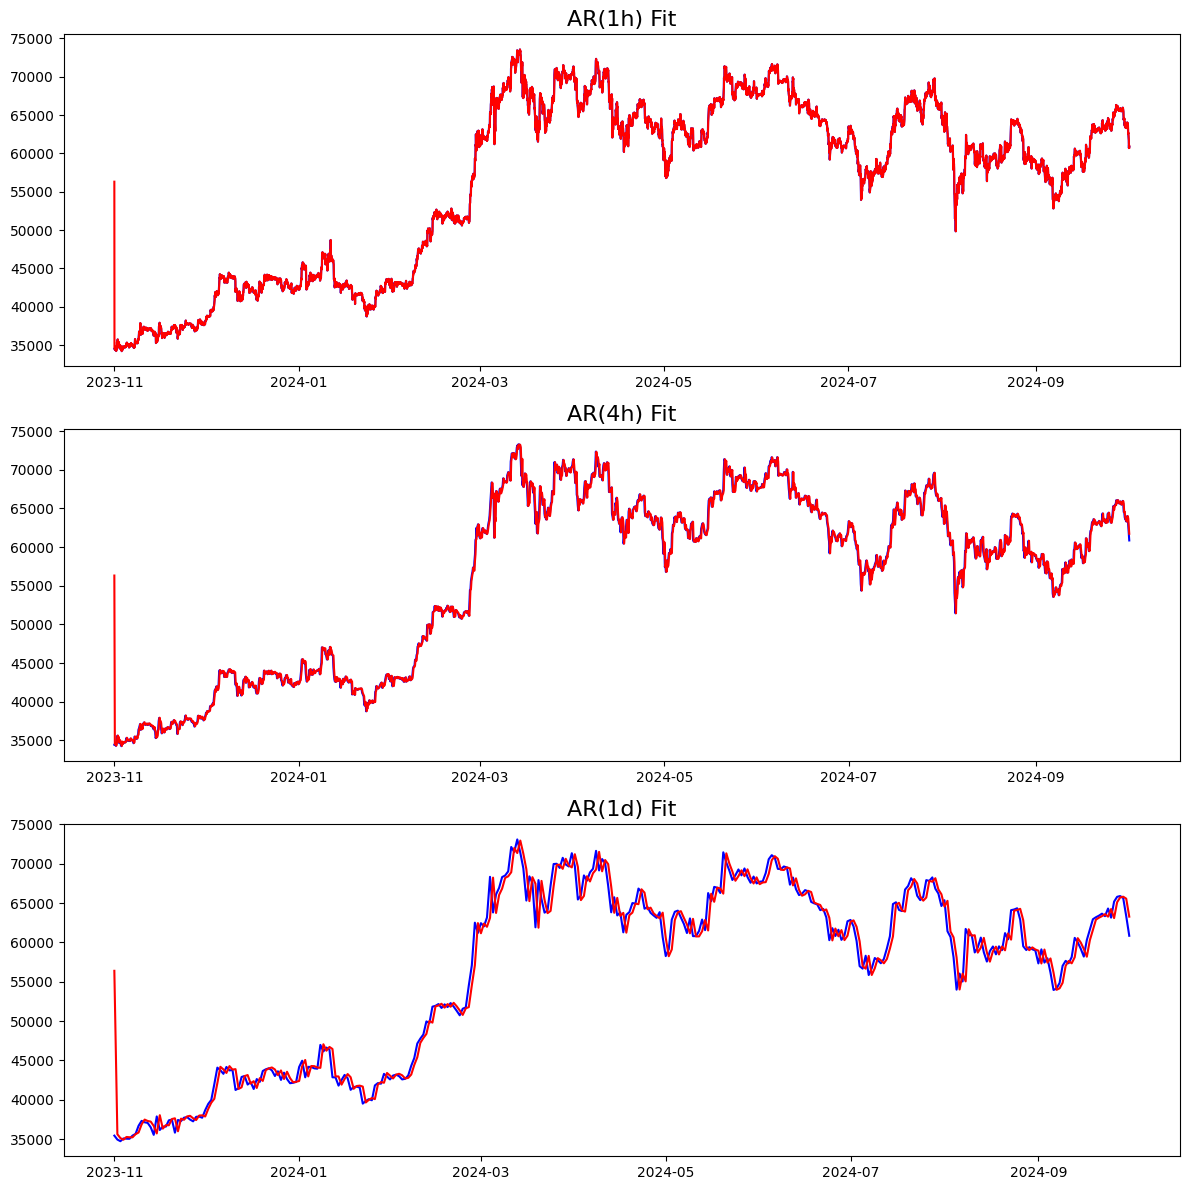

In [168]:
plt.figure(figsize=(12,12))

ar_orders = [1, 1, 1]
series = [train_data_1h, train_data_4h, train_data_1d]
fitted_model_dict = {}

original_color = 'blue'   
fitted_color = 'red'  

for idx, ar_order in enumerate(ar_orders):
    ar_model = ARIMA(series[idx], order=(ar_order,0,0))
    ar_model_fit = ar_model.fit()
    print(ar_model_fit.summary())
    fitted_model_dict[time_frames[idx]] = ar_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(ar_model_fit.fittedvalues, color=fitted_color)
    plt.title('AR(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

Time Frame: 1h
MSE:  40523807.72740243
MAPE 0.07628766562399766


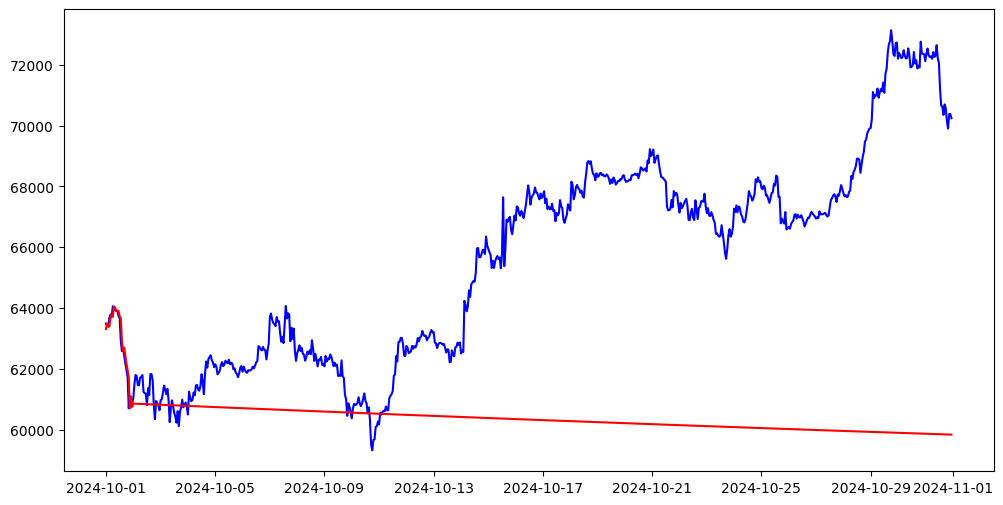

Time Frame: 4h
MSE:  40455565.51561098
MAPE 0.07652439611845295


<Figure size 640x480 with 0 Axes>

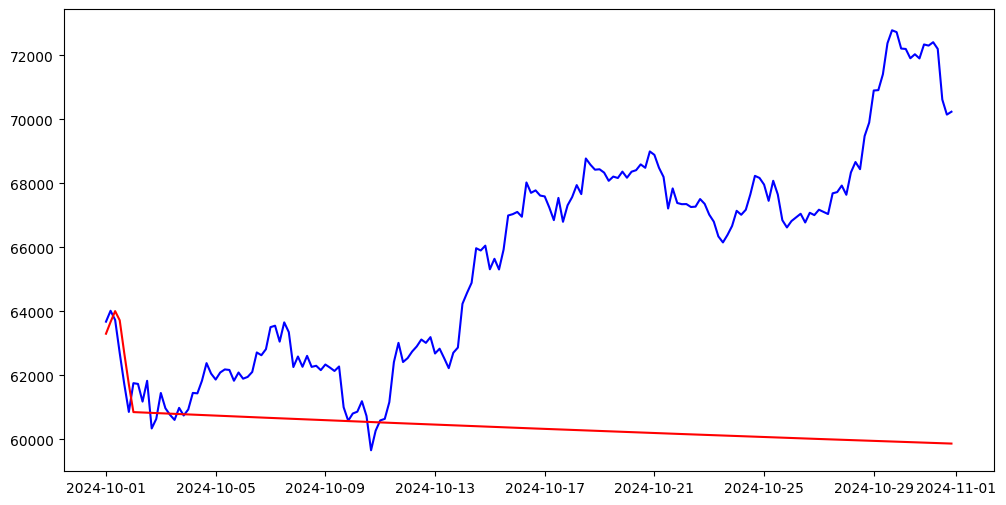

Time Frame: 1d
MSE:  42873454.98138591
MAPE 0.07910362440921423


<Figure size 640x480 with 0 Axes>

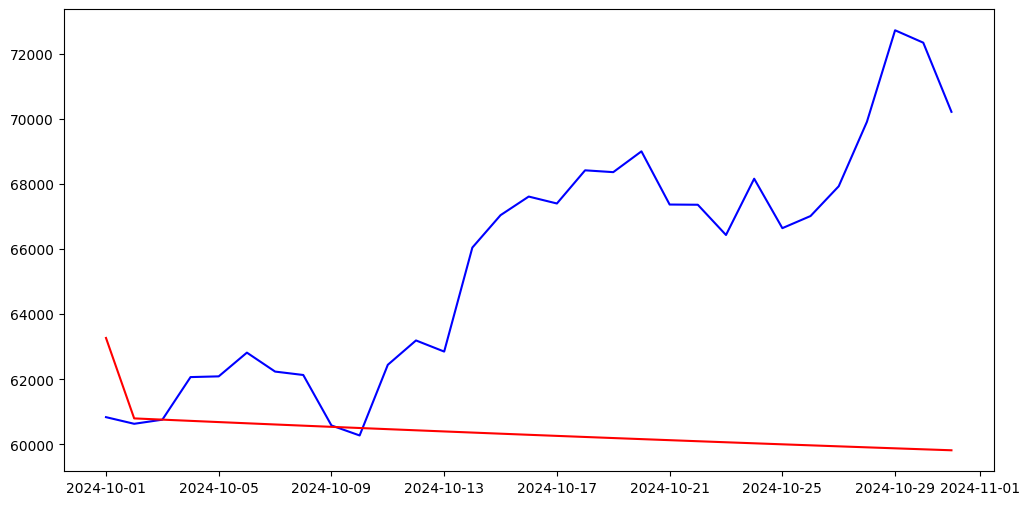

<Figure size 640x480 with 0 Axes>

In [169]:
series = [test_data_1h, test_data_4h, test_data_1d]

for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict[time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()

### MA Models

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8064
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -81183.963
Date:                Mon, 16 Dec 2024   AIC                         162373.925
Time:                        21:25:12   BIC                         162394.911
Sample:                    11-01-2023   HQIC                        162381.105
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.632e+04    127.192    442.782      0.000    5.61e+04    5.66e+04
ma.L1          0.9813      0.002    423.502      0.000       0.977       0.986
sigma2      3.249e+07      0.011   2.95e+09      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


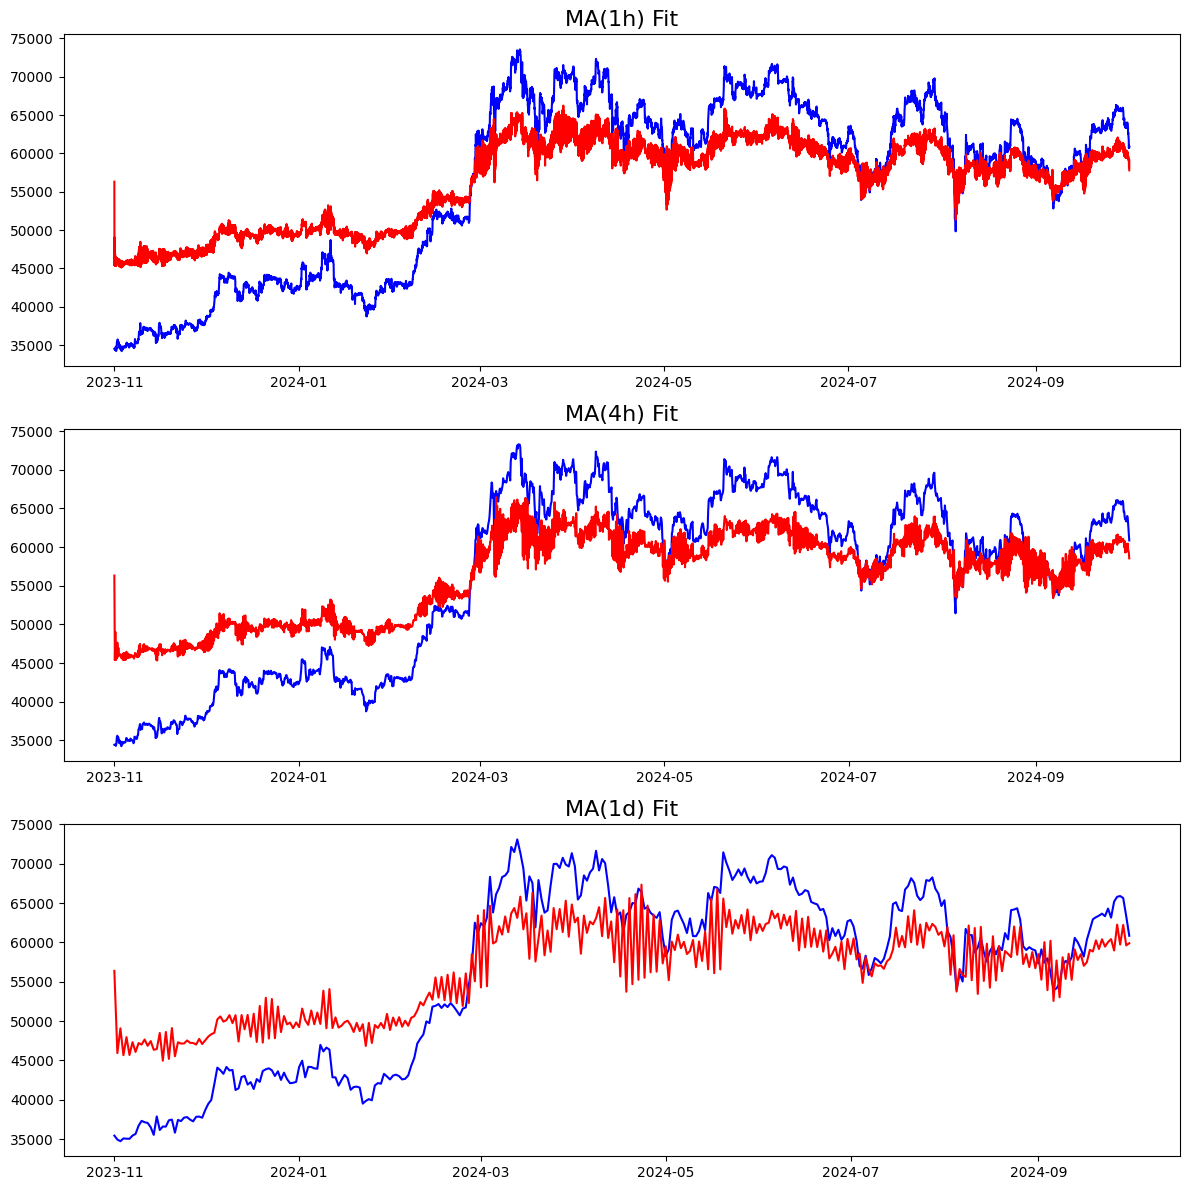

In [172]:
plt.figure(figsize=(12,12))

ma_orders = [1, 1, 1]
series = [train_data_1h, train_data_4h, train_data_1d]
fitted_model_dict = {}

original_color = 'blue'   
fitted_color = 'red'  

for idx, ma_order in enumerate(ma_orders):
    ma_model = ARIMA(series[idx], order=(0,0,ma_order))
    ma_model_fit = ma_model.fit()
    print(ma_model_fit.summary())
    fitted_model_dict[time_frames[idx]] = ma_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(ma_model_fit.fittedvalues, color=fitted_color)
    plt.title('MA(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

Time Frame: 1h
MSE:  95777076.48808223
MAPE 0.13678621702791566


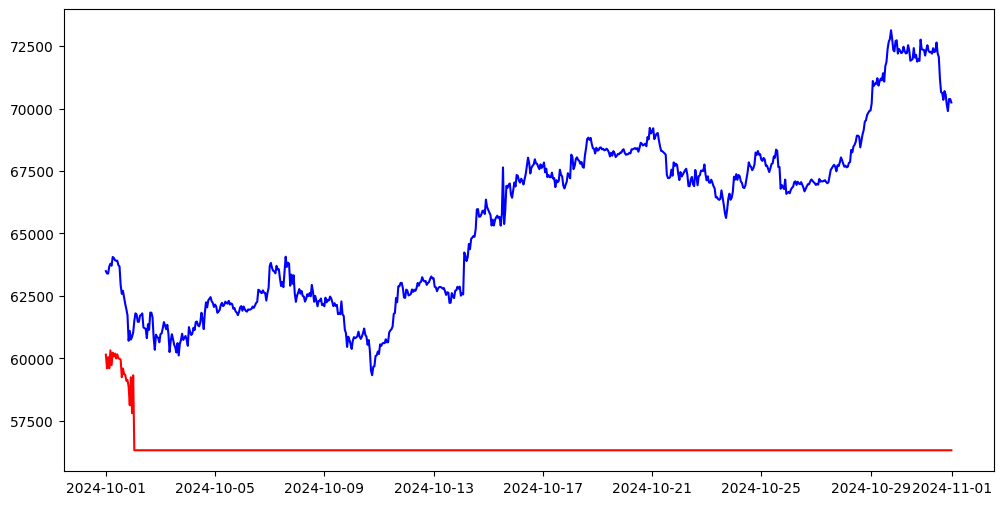

Time Frame: 4h
MSE:  95948371.30135652
MAPE 0.13686557017937984


<Figure size 640x480 with 0 Axes>

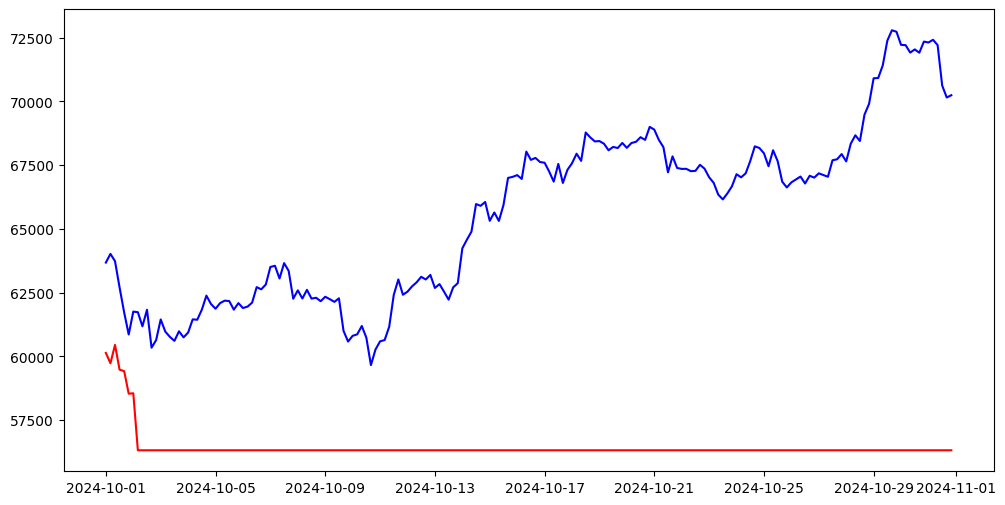

Time Frame: 1d
MSE:  96594332.31860583
MAPE 0.13533834317768234


<Figure size 640x480 with 0 Axes>

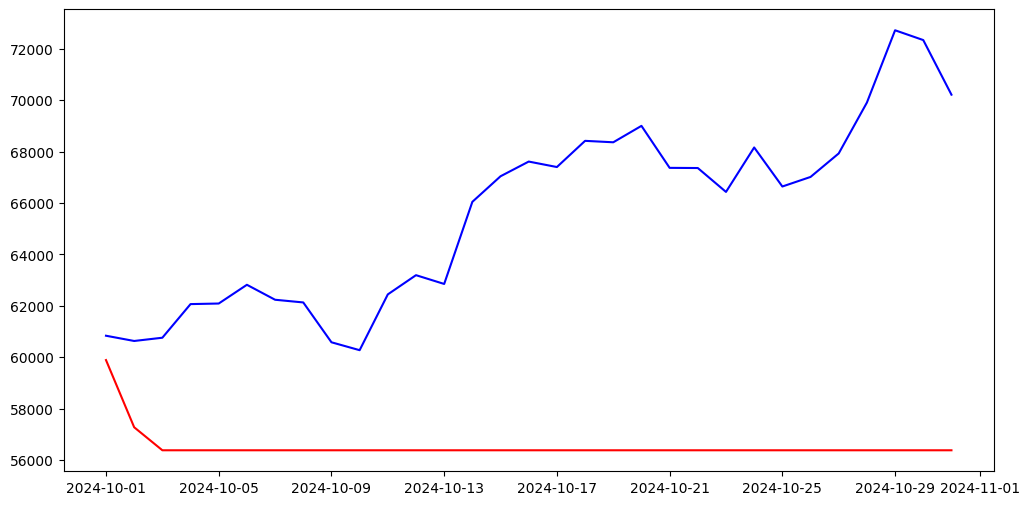

<Figure size 640x480 with 0 Axes>

In [173]:
series = [test_data_1h, test_data_4h, test_data_1d]

for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict[time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()

### ARMA Models

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8064
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -57855.400
Date:                Mon, 16 Dec 2024   AIC                         115718.800
Time:                        21:26:17   BIC                         115746.781
Sample:                    11-01-2023   HQIC                        115728.373
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.632e+04   3729.070     15.103      0.000     4.9e+04    6.36e+04
ar.L1          0.9994      0.000   3886.234      0.000       0.999       1.000
ma.L1          0.0074      0.006      1.335      0.1

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


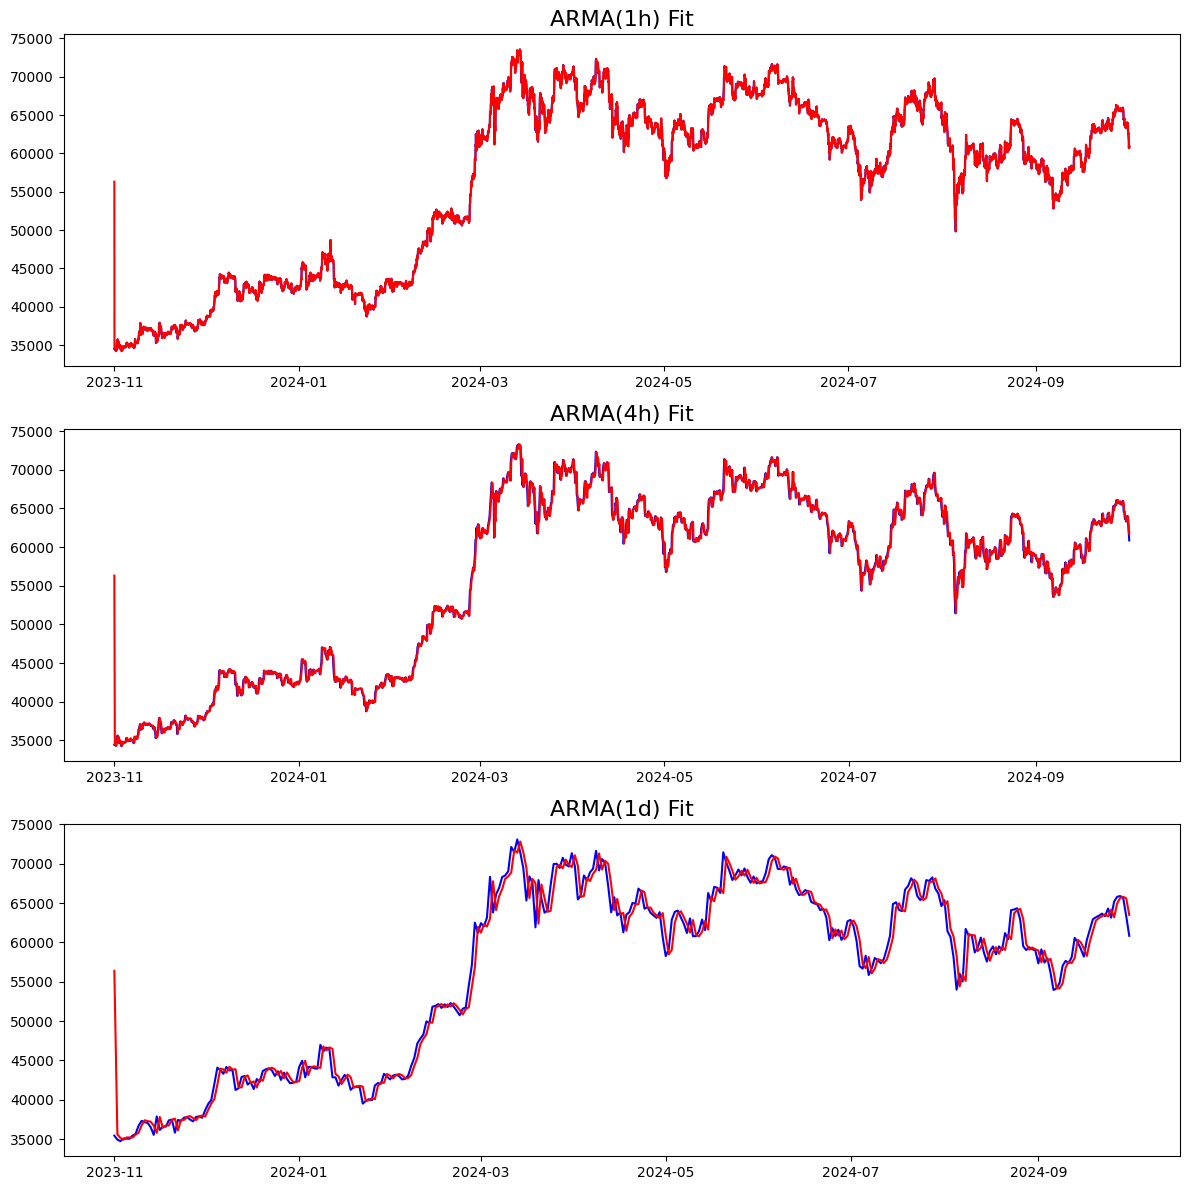

In [174]:
plt.figure(figsize=(12,12))

series = [train_data_1h, train_data_4h, train_data_1d]
fitted_model_dict = {}

original_color = 'blue'   
fitted_color = 'red'  

for idx, ma_order in enumerate(ma_orders):
    arma_model = ARIMA(series[idx], order=(1,0,1))
    arma_model_fit = arma_model.fit()
    print(arma_model_fit.summary())
    fitted_model_dict[time_frames[idx]] = arma_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(arma_model_fit.fittedvalues, color=fitted_color)
    plt.title('ARMA(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

Time Frame: 1h
MSE:  45561260.888717204
MAPE 0.08132119681652632


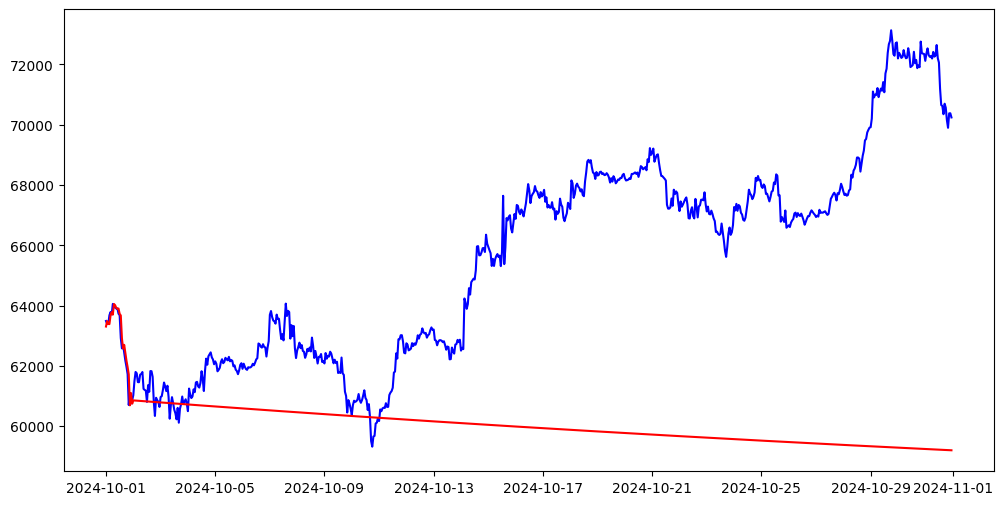

Time Frame: 4h
MSE:  39532518.89520492
MAPE 0.07554038845378018


<Figure size 640x480 with 0 Axes>

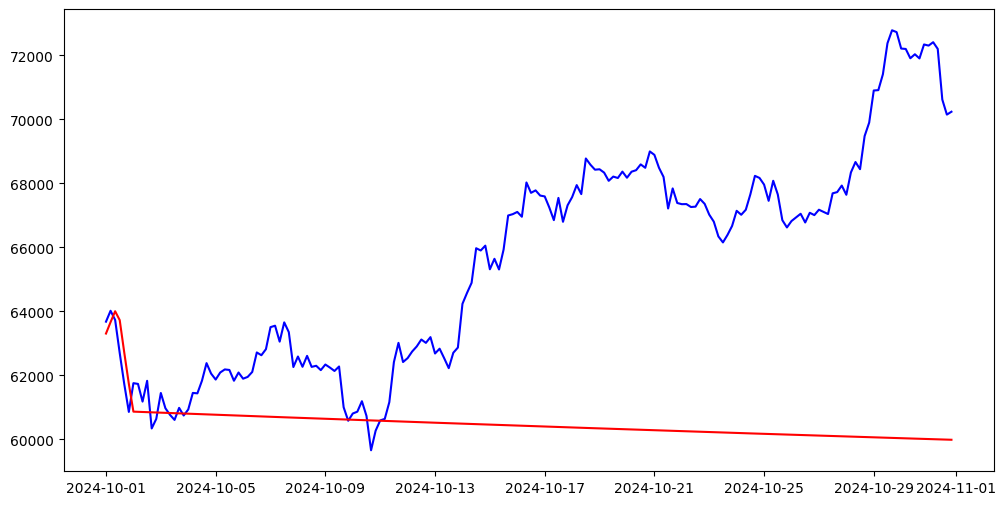

Time Frame: 1d
MSE:  39328961.3166158
MAPE 0.07558822636856079


<Figure size 640x480 with 0 Axes>

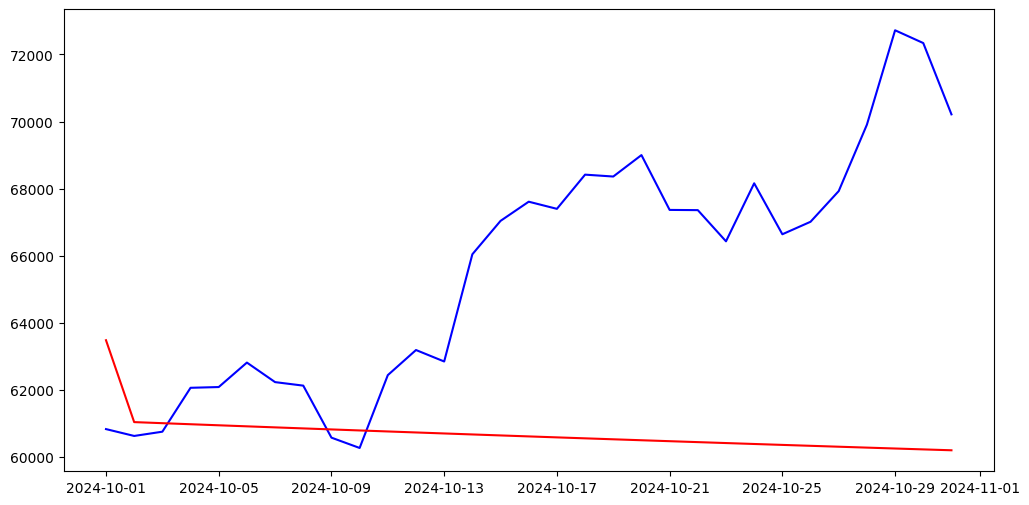

<Figure size 640x480 with 0 Axes>

In [175]:
series = [test_data_1h, test_data_4h, test_data_1d]

for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict[time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()

### Making Stationary

In [246]:
coin = 'BTC-USD'  
series_1d = all_data[coin]['1d']['Close'].dropna()
series_4h = all_data[coin]['4h']['Close'].dropna()  
series_1h = all_data[coin]['1h']['Close'].dropna()

series = [series_1h, series_4h, series_1d]

##### Normalization (Not Applied!)

In [ ]:
for idx, serie in enumerate(series):
    avg, dev = serie.mean(), serie.std()
    serie = (serie - avg) / dev
    series[idx] = serie
     
    plt.figure(figsize=(12,6))
    plt.plot(serie, color='red')
    plt.title(f"{coin}-{time_frames[idx]}")
    plt.show()
    plt.tight_layout()

##### First Difference

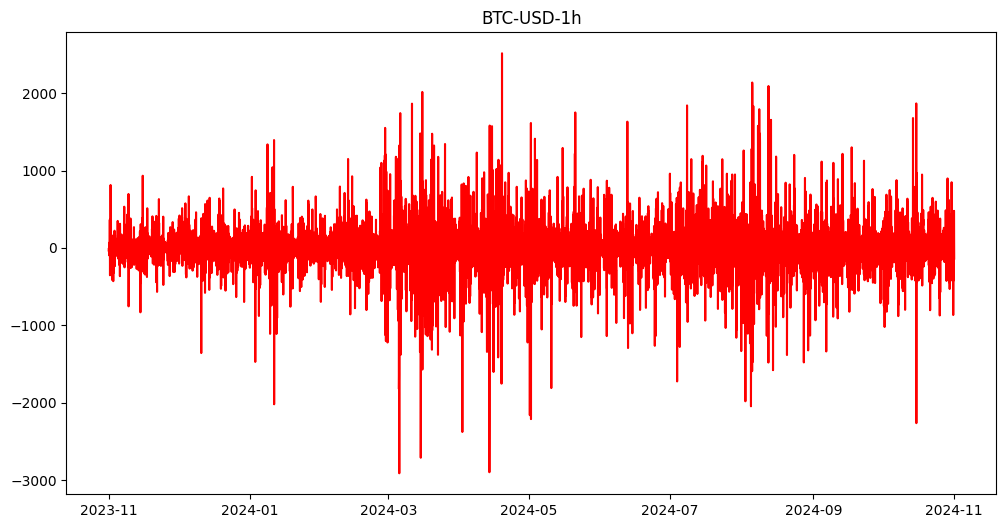

<Figure size 640x480 with 0 Axes>

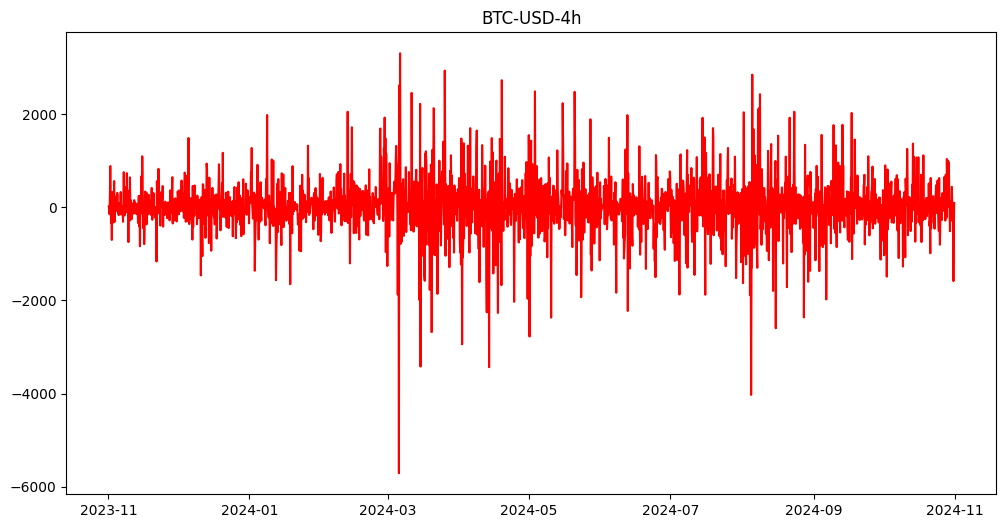

<Figure size 640x480 with 0 Axes>

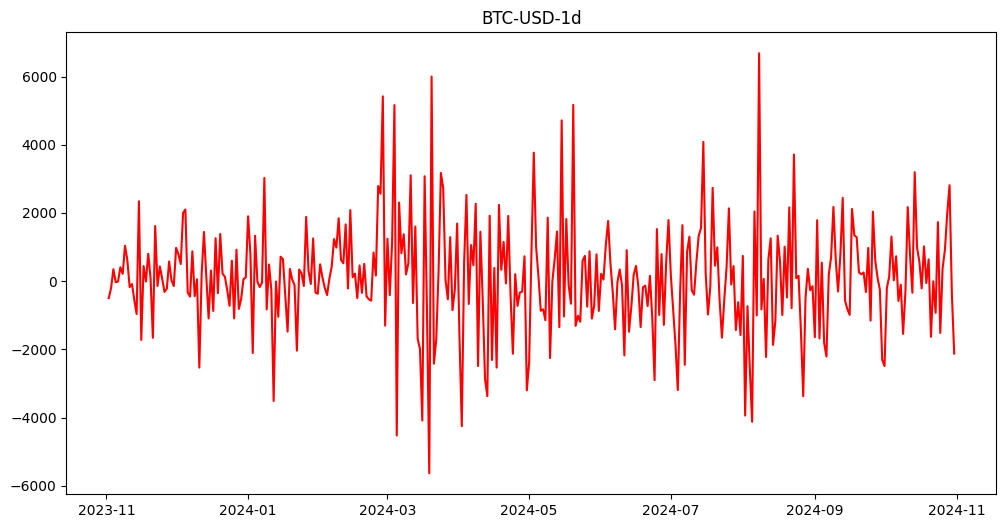

<Figure size 640x480 with 0 Axes>

In [247]:
for idx, serie in enumerate(series):
    serie = serie.diff().dropna()
    series[idx] = serie
    
    plt.figure(figsize=(12,6))
    plt.plot(serie, color='red')
    plt.title(f"{coin}-{time_frames[idx]}")
    plt.show()
    plt.tight_layout()

### Check Stationary Status

In [248]:
for idx, serie in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    res = adfuller(serie)
    stats, pvalue = res[0], res[1]
    print(f"ADF Statistics: {stats}\tP-value: {pvalue}")
    if pvalue < 0.1:
        print("Stationary!")
    else:
        print("Non-Stationary!")
    print(50*"=")

Time Frame: 1h
ADF Statistics: -17.428147596206617	P-value: 4.783798962276948e-30
Stationary!
Time Frame: 4h
ADF Statistics: -10.710247324819449	P-value: 3.3461901954354234e-19
Stationary!
Time Frame: 1d
ADF Statistics: -20.91573567733209	P-value: 0.0
Stationary!


### ACF & PACF

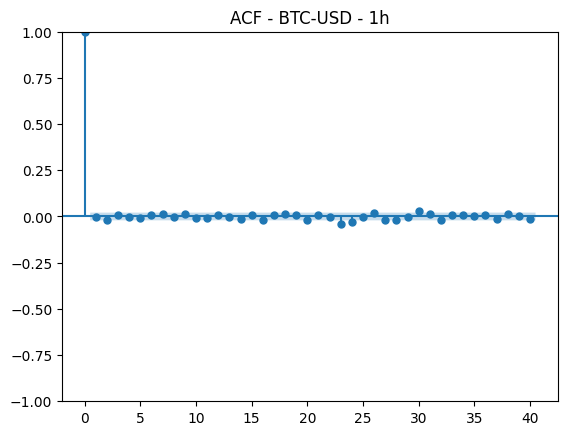

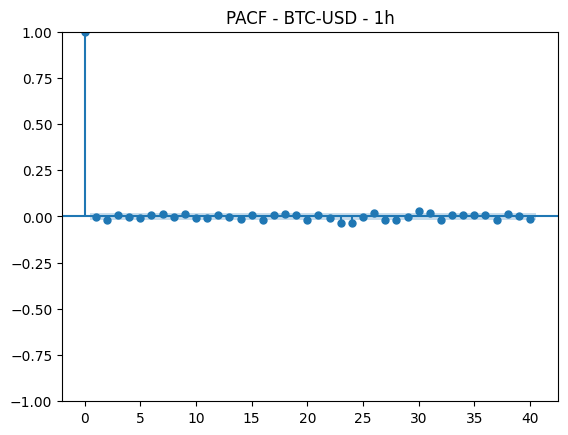

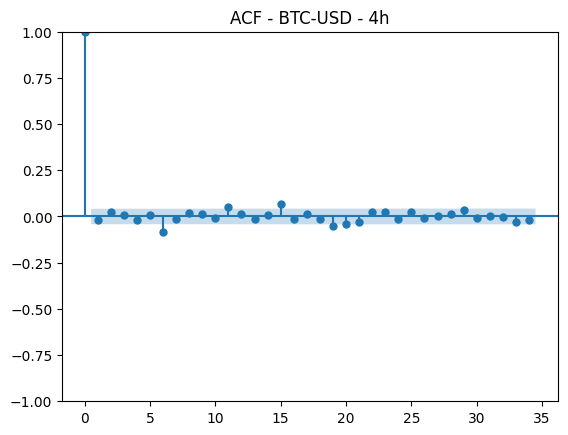

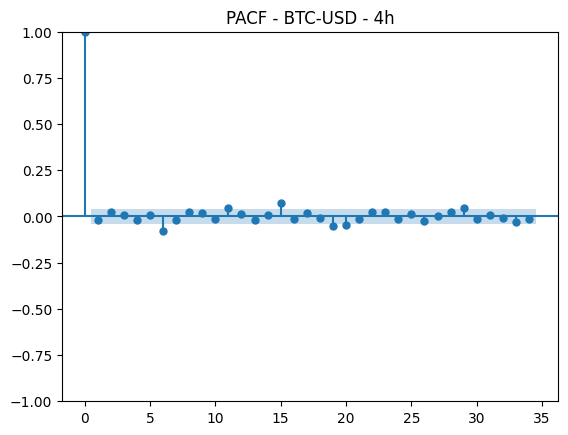

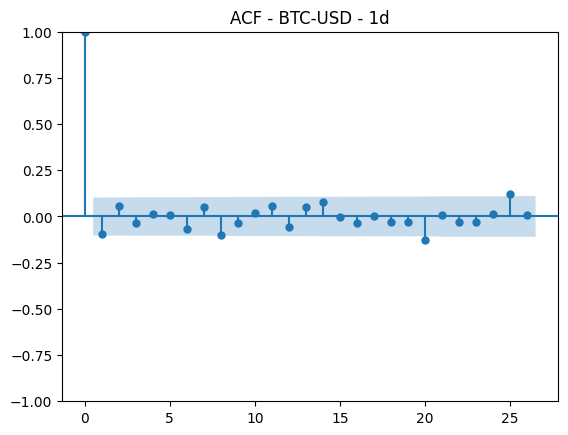

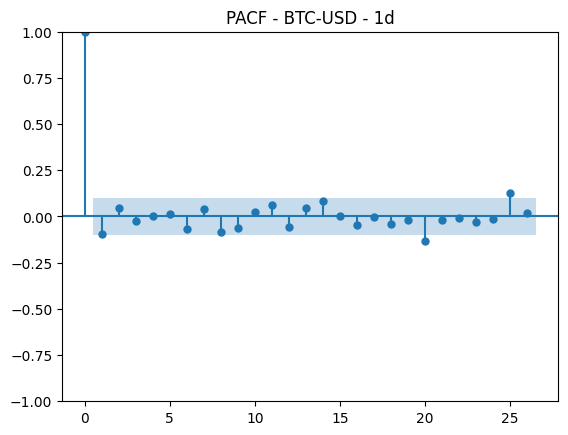

In [249]:
coin = 'BTC-USD'
for idx, serie in enumerate(series):
    plot_acf(serie, title=f"ACF - {coin} - {time_frames[idx]}")
    plot_pacf(serie, title=f"PACF - {coin} - {time_frames[idx]}")

### Data Split

In [250]:
train_data_1d = series[2][:'2024-10-01']
test_data_1d = series[2]['2024-10-01':]

train_data_4h = series[1][:'2024-10-01']
test_data_4h = series[1]['2024-10-01':]

train_data_1h = series[0][:'2024-10-01']
test_data_1h = series[0]['2024-10-01':]

In [261]:
fitted_model_dict = {"AR": {}, "MA": {}, "ARMA": {}}

ar_orders = [2, 6, 1]
ma_orders = [2, 6, 1]

In [260]:
series = [train_data_1h, train_data_4h, train_data_1d]

### Fit AR, MA and ARIMA Model

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8063
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -57842.525
Date:                Mon, 16 Dec 2024   AIC                         115693.050
Time:                        22:05:19   BIC                         115721.030
Sample:                    11-01-2023   HQIC                        115702.623
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2659      3.504      0.932      0.351      -3.603      10.134
ar.L1          0.0064      0.006      1.143      0.253      -0.005       0.017
ar.L2         -0.0190      0.007     -2.662      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


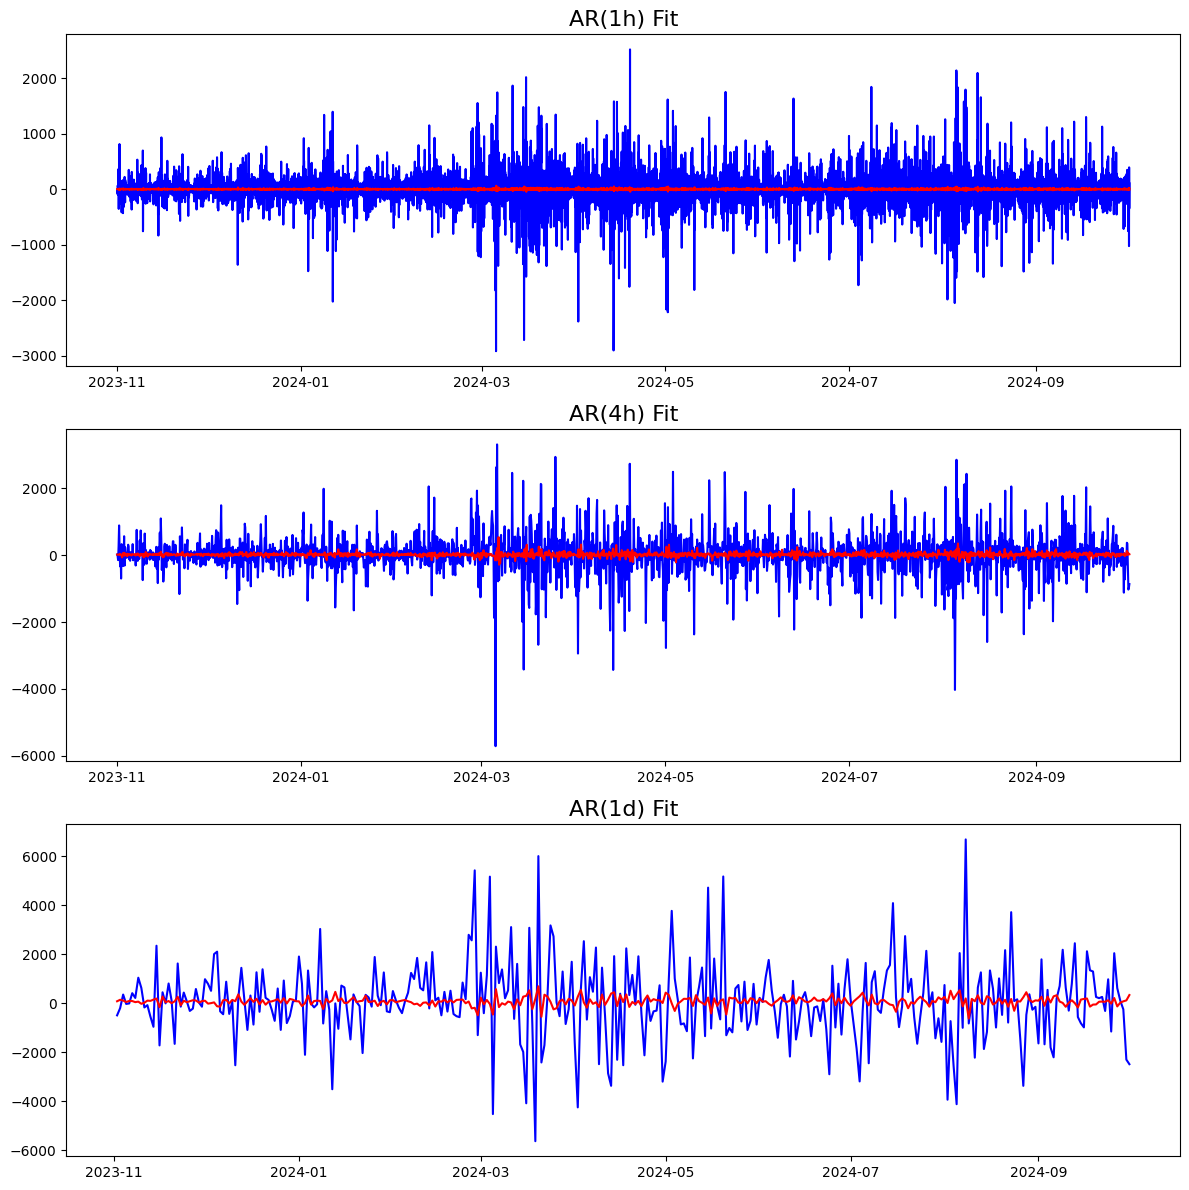

In [262]:
plt.figure(figsize=(12,12))

original_color = 'blue'   
fitted_color = 'red'  

for idx, (ar_order) in enumerate(ar_orders):
    ar_model = ARIMA(series[idx], order=(ar_order,0,0))
    ar_model_fit = ar_model.fit()
    print(ar_model_fit.summary())
    fitted_model_dict["AR"][time_frames[idx]] = ar_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(ar_model_fit.fittedvalues, color=fitted_color)
    plt.title('AR(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 8063
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -57842.504
Date:                Mon, 16 Dec 2024   AIC                         115693.008
Time:                        22:05:26   BIC                         115720.988
Sample:                    11-01-2023   HQIC                        115702.581
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2659      3.508      0.931      0.352      -3.609      10.141
ma.L1          0.0068      0.006      1.216      0.224      -0.004       0.018
ma.L2         -0.0191      0.007     -2.669      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


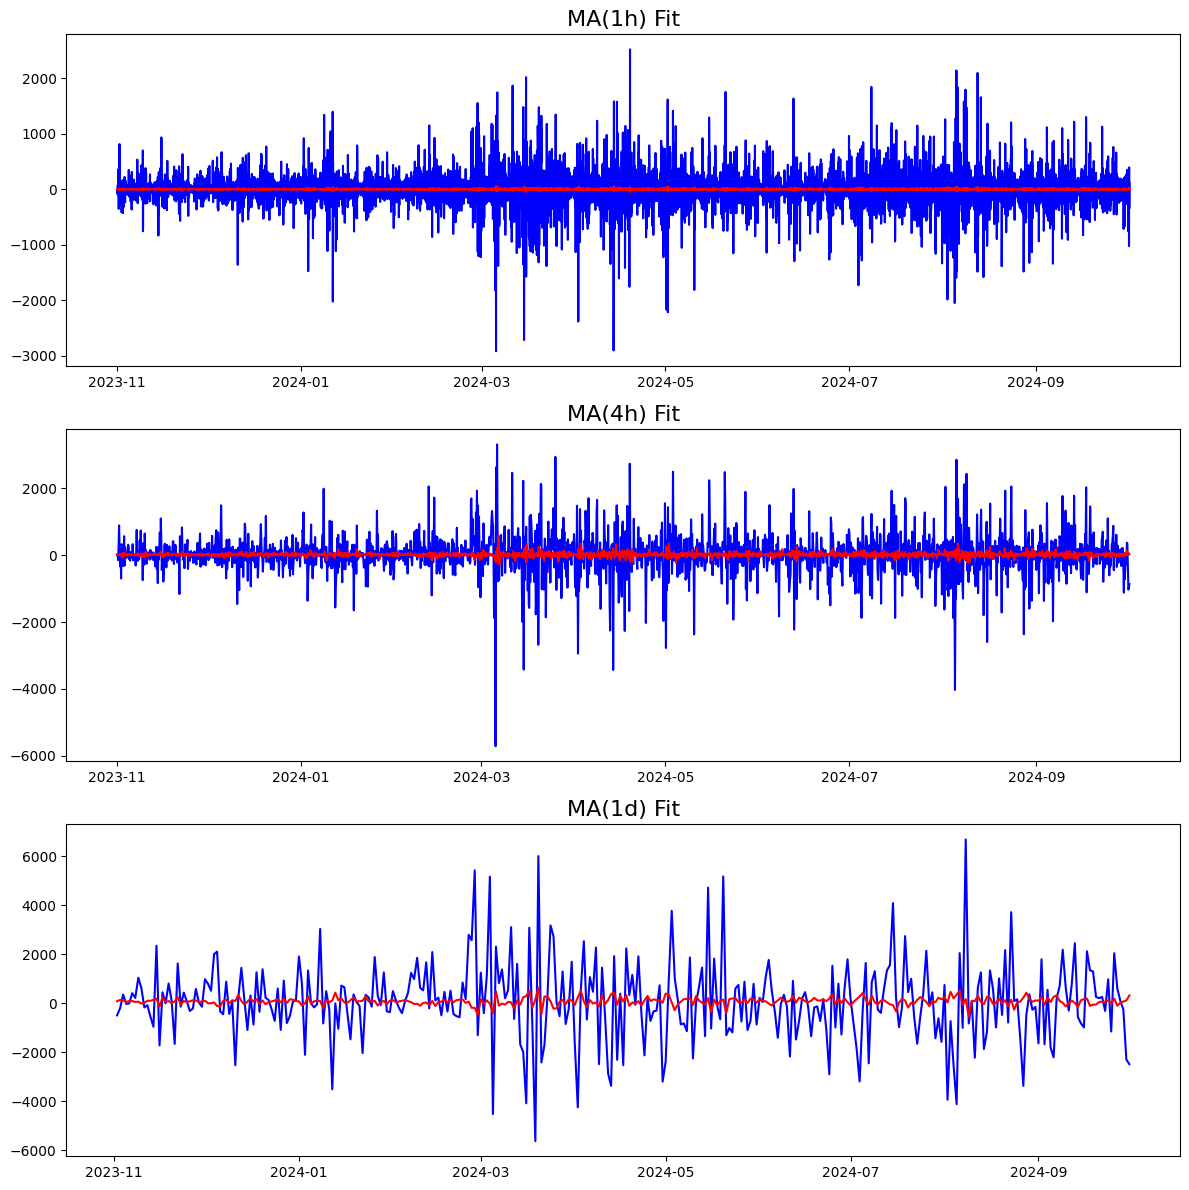

In [263]:
plt.figure(figsize=(12,12))

original_color = 'blue'   
fitted_color = 'red'  

for idx, (ma_order) in enumerate(ma_orders):
    ma_model = ARIMA(series[idx], order=(0,0,ma_order))
    ma_model_fit = ma_model.fit()
    print(ma_model_fit.summary())
    fitted_model_dict["MA"][time_frames[idx]] = ma_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(ma_model_fit.fittedvalues, color=fitted_color)
    plt.title('MA(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  335
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2947.464
Date:                Mon, 16 Dec 2024   AIC                           5900.928
Time:                        22:05:41   BIC                           5912.370
Sample:                    11-02-2023   HQIC                          5905.489
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.8202     81.132      0.935      0.350     -83.196     234.836
ar.L1         -0.1070      0.045     -2.404      0.016      -0.194      -0.020
sigma2      2.575e+06   1.38e+05     18.703      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  335
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2947.464
Date:                Mon, 16 Dec 2024   AIC                           5900.928
Time:                        22:05:47   BIC                           5912.370
Sample:                    11-02-2023   HQIC                          5905.489
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.8202     81.132      0.935      0.350     -83.196     234.836
ar.L1         -0.1070      0.045     -2.404      0.016      -0.194      -0.020
sigma2      2.575e+06   1.38e+05     18.703      0.0

c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\efnhm\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


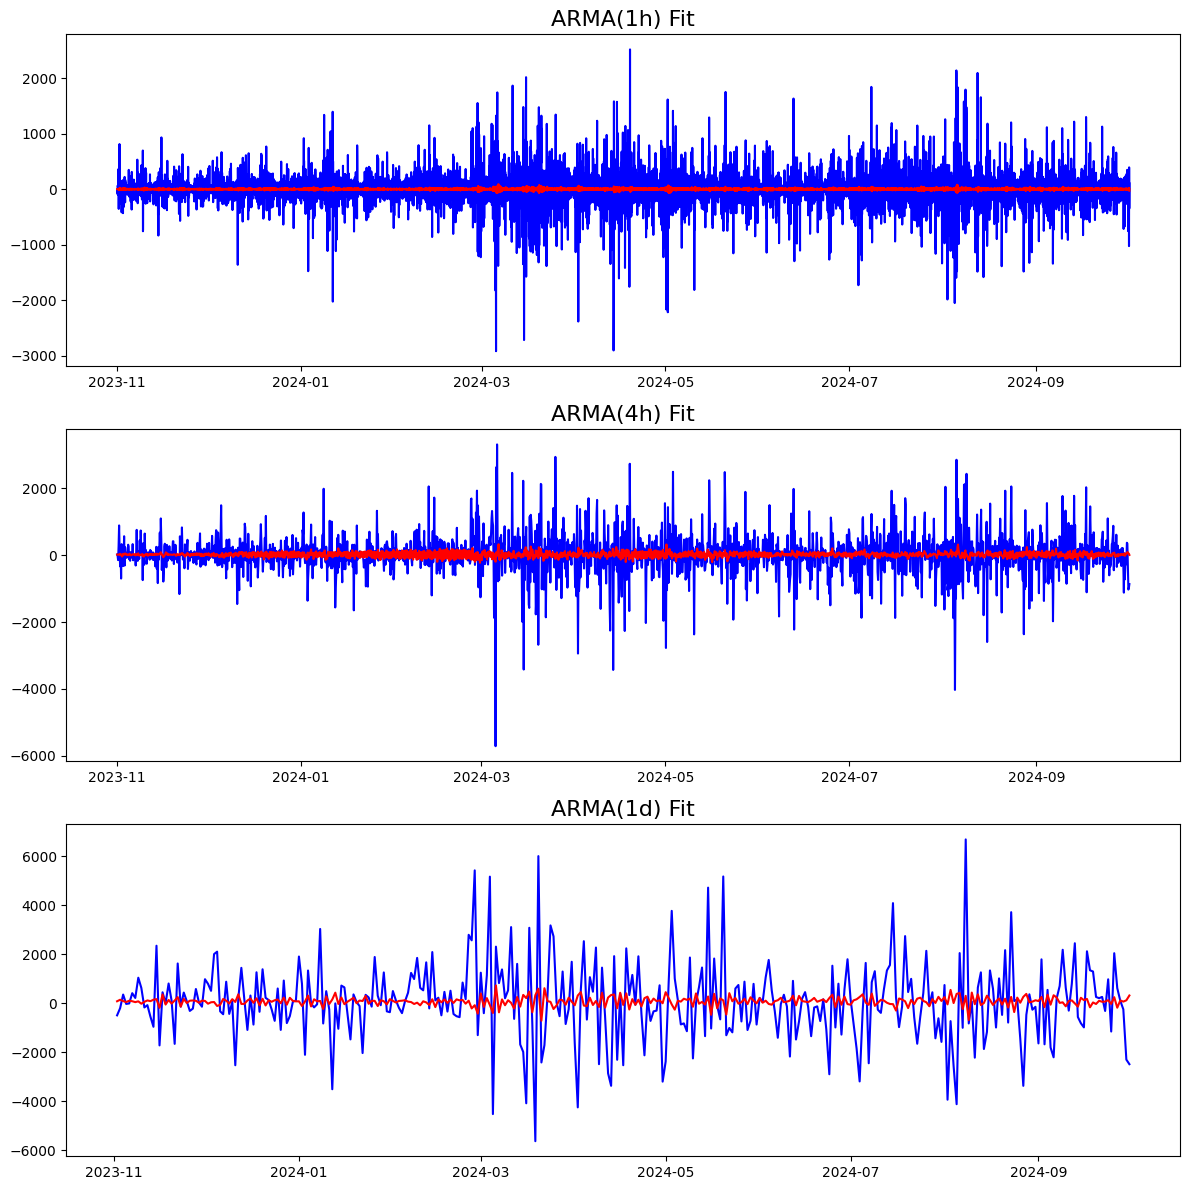

In [264]:
plt.figure(figsize=(12,12))

original_color = 'blue'   
fitted_color = 'red'  

for idx, (ar_order, ma_order) in enumerate(zip(ar_orders, ma_orders)):
    arma_model = ARIMA(series[idx], order=(ar_order,0,ma_order))
    arma_model_fit = arma_model.fit()
    print(ar_model_fit.summary())
    fitted_model_dict["ARMA"][time_frames[idx]] = arma_model_fit
    plt.subplot(3,1,idx+1)
    plt.plot(series[idx], color=original_color)
    plt.plot(arma_model_fit.fittedvalues, color=fitted_color)
    plt.title('ARMA(%s) Fit'%time_frames[idx], fontsize=16)

plt.tight_layout()

In [265]:
series = [test_data_1h, test_data_4h, test_data_1d]

Time Frame: 1h
MSE:  80116.26504471489
MAPE:  1.2368568420686252


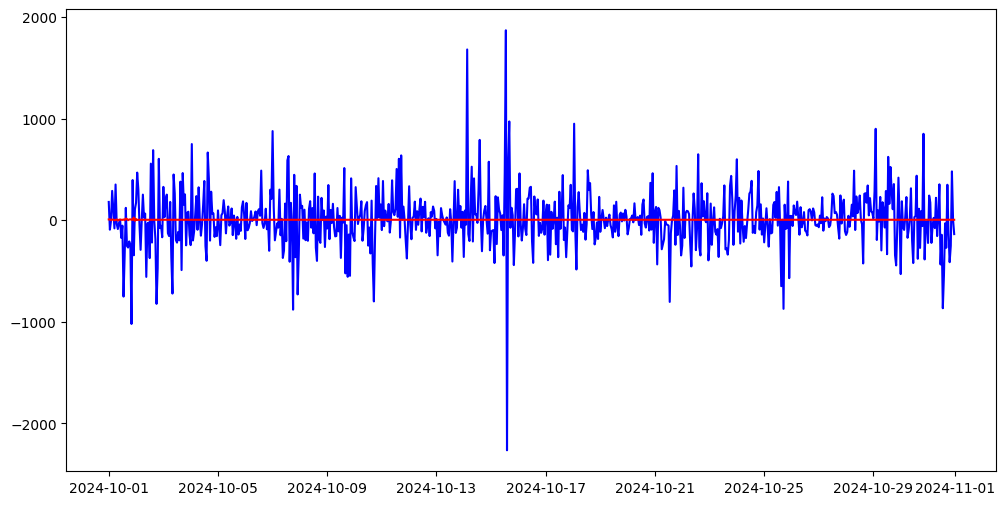

Time Frame: 4h
MSE:  235972.38688538992
MAPE:  1.005190161301767


<Figure size 640x480 with 0 Axes>

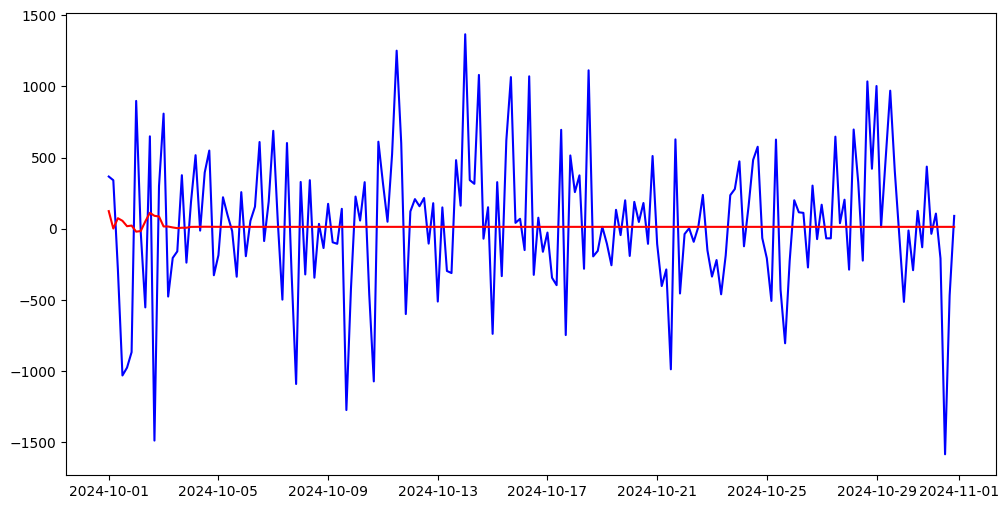

Time Frame: 1d
MSE:  1831807.115319515
MAPE:  1.5476250163843146


<Figure size 640x480 with 0 Axes>

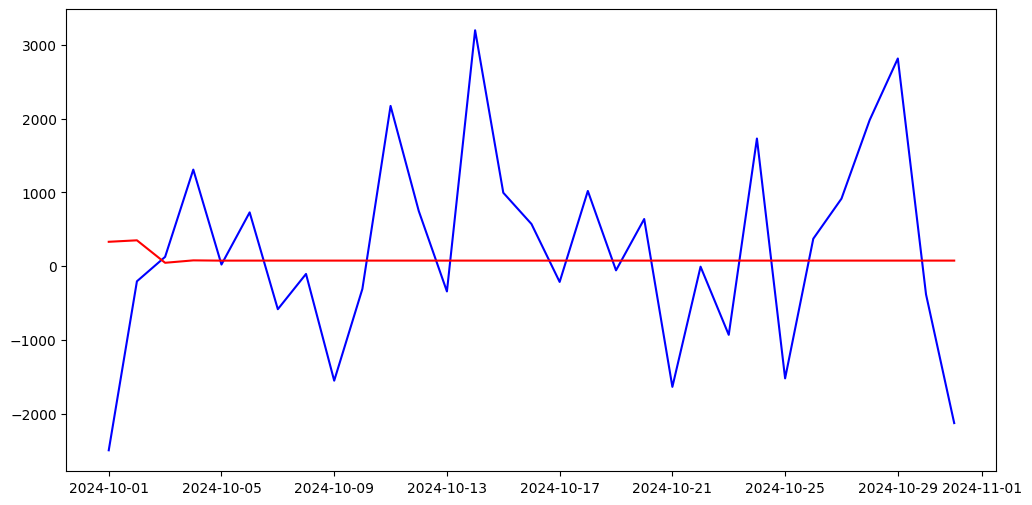

<Figure size 640x480 with 0 Axes>

In [266]:
for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict["AR"][time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE: ", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()

Time Frame: 1h
MSE:  80116.51191755784
MAPE:  1.236808426333056


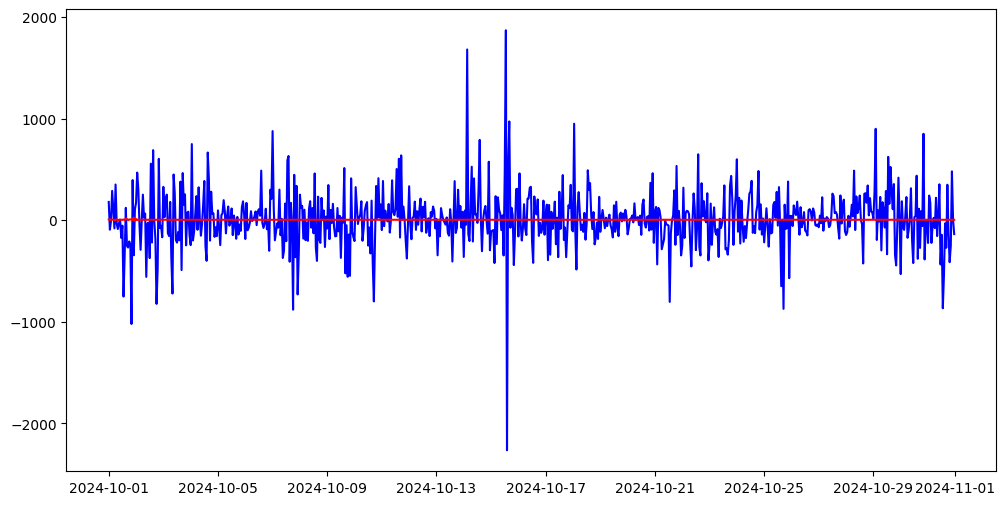

Time Frame: 4h
MSE:  235771.96038785335
MAPE:  1.004729333721175


<Figure size 640x480 with 0 Axes>

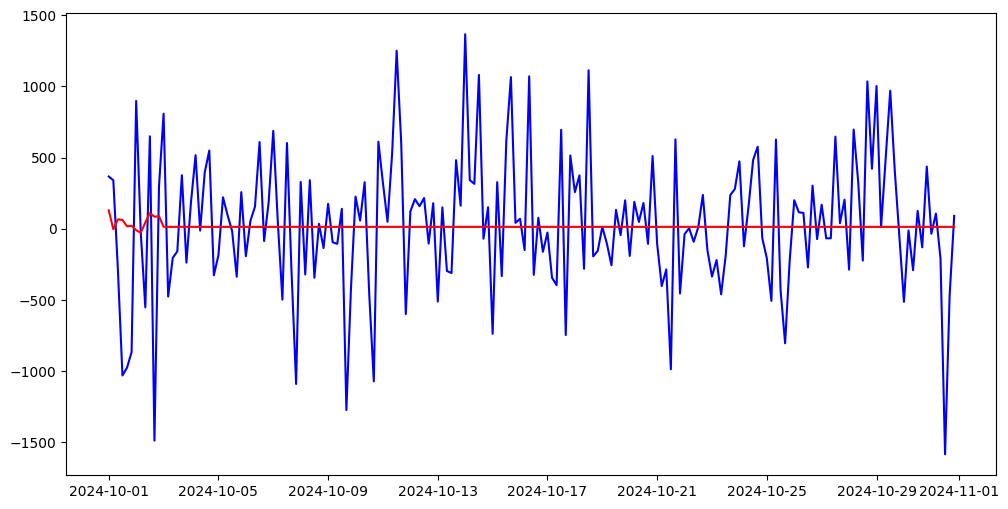

Time Frame: 1d
MSE:  1828310.302767118
MAPE:  1.5401965226165202


<Figure size 640x480 with 0 Axes>

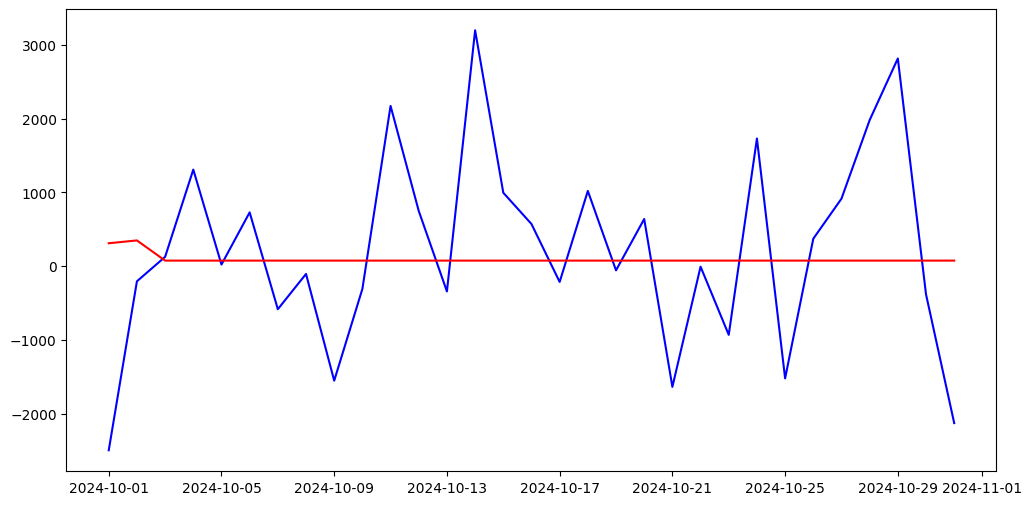

<Figure size 640x480 with 0 Axes>

In [267]:
for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict["MA"][time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE: ", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()

Time Frame: 1h
MSE:  80067.83473629122
MAPE:  1.239858482575341


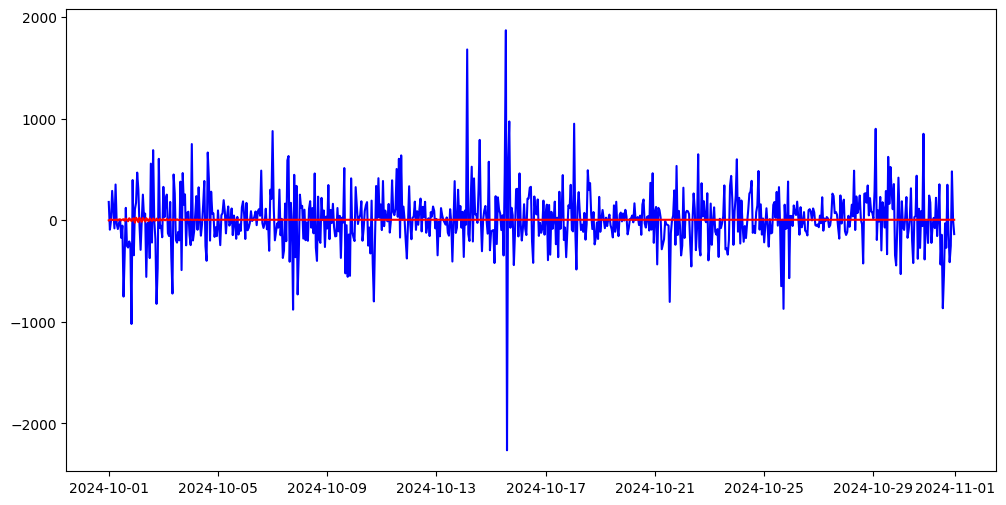

Time Frame: 4h
MSE:  235028.81369771535
MAPE:  0.9978357915001379


<Figure size 640x480 with 0 Axes>

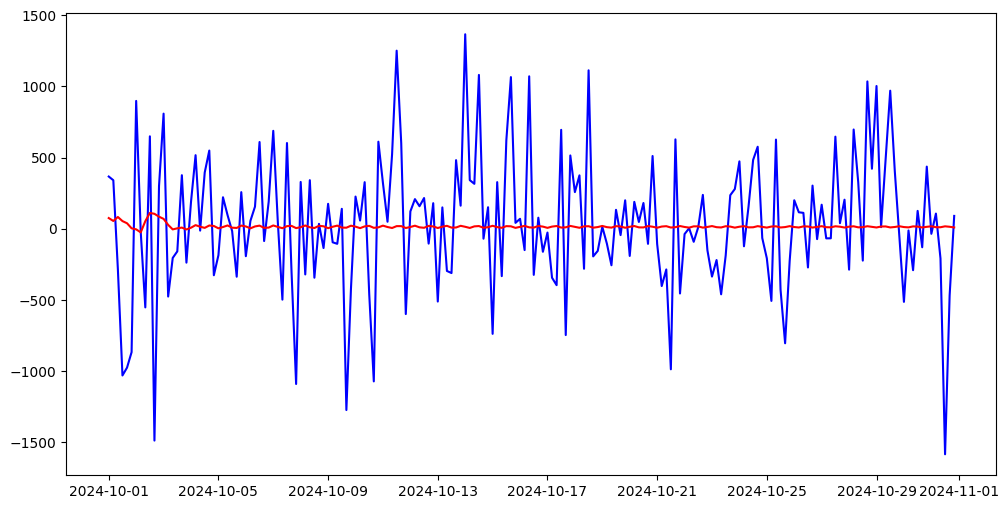

Time Frame: 1d
MSE:  1822754.5579286774
MAPE:  1.5234335289886143


<Figure size 640x480 with 0 Axes>

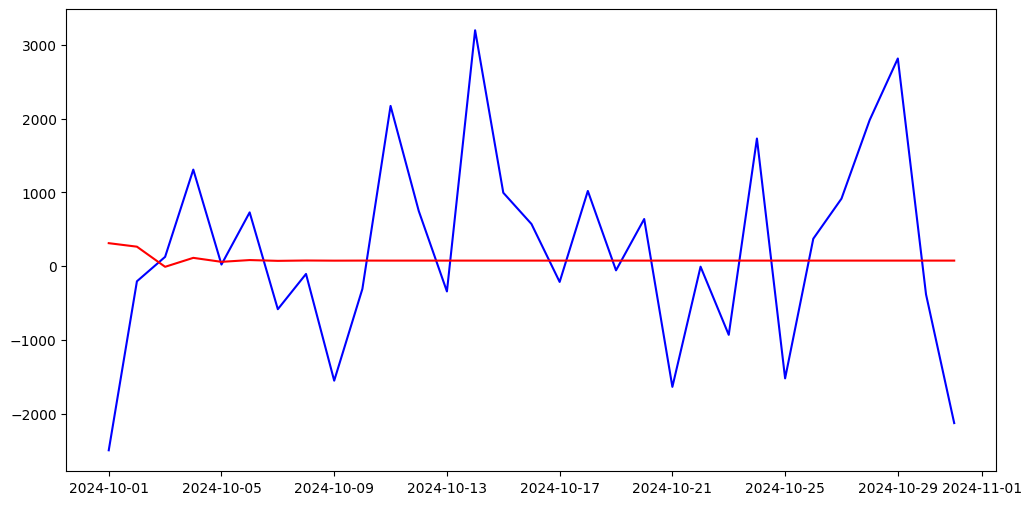

<Figure size 640x480 with 0 Axes>

In [268]:
for idx, test_data in enumerate(series):
    print(f"Time Frame: {time_frames[idx]}")
    pred_start_date = test_data.index[0]
    pred_end_date = test_data.index[-1]

    predictions = fitted_model_dict["ARMA"][time_frames[idx]].predict(start=pred_start_date, end=pred_end_date)

    print("MSE: ", mean_squared_error(test_data, predictions))
    print("MAPE: ", mean_absolute_percentage_error(test_data, predictions))

    original_color = 'blue'   
    fitted_color = 'red'
    plt.figure(figsize=(12,6))
    plt.plot(test_data, color=original_color)
    plt.plot(predictions, color=fitted_color)
    plt.show()
    plt.tight_layout()